<a href="https://colab.research.google.com/github/Nikoldbautista/Introduccion_ciencia_de_datos-/blob/main/Parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuración de datos para que sea igual a tu examen
np.random.seed(42)
n = 1000

# Lógica de rangos (Sueldo Min, Sueldo Max, Probabilidad de Outlier)
logica = {
    'Bachiller':   (1100, 1800, 0.01),
    'Técnico':     (1600, 2300, 0.01),
    'Profesional': (2200, 3800, 0.03),
    'Maestría':    (3500, 5500, 0.05),
    'Doctorado':   (5000, 8000, 0.10)
}

registros = []
for i in range(1, n + 1):
    nivel = np.random.choice(list(logica.keys()))
    s_min, s_max, p_out = logica[nivel]

    # Decidir sueldo (Normal vs Outlier tipo Cliente 5)
    if np.random.random() < p_out:
        sueldo_num = np.random.randint(40000, 50000)
    else:
        sueldo_num = np.random.randint(s_min, s_max)

    # Creamos la fila con todas las columnas del examen
    registros.append({
        'ID Cliente': i,
        'Edad': np.random.randint(18, 65),
        'Salario Mensual (USD)': f"${sueldo_num:,}", # Formato texto para la tabla
        'Sueldo_Num': sueldo_num,                    # Columna oculta para cálculos
        'Nivel Educativo': nivel,
        'Crédito Aprobado': np.random.choice(['Sí', 'No'], p=[0.6, 0.4])
    })

# CREAMOS EL DATAFRAME
df = pd.DataFrame(registros)

# 2. MOSTRAR LA TABLA (Lo que me pediste)
# Quitamos 'Sueldo_Num' del print para que se vea limpiecito como tu examen

print(df.drop(columns=['Sueldo_Num']).head(10))



   ID Cliente  Edad Salario Mensual (USD) Nivel Educativo Crédito Aprobado
0           1    25                $4,630        Maestría               Sí
1           2    28                $1,930         Técnico               No
2           3    39                $3,630        Maestría               Sí
3           4    38                $3,885        Maestría               No
4           5    44                $2,160         Técnico               No
5           6    33                $2,299         Técnico               Sí
6           7    20                $3,467     Profesional               No
7           8    21                $6,297       Doctorado               No
8           9    19                $1,945         Técnico               No
9          10    25                $4,008        Maestría               Sí


Tres graficos, analizar los graficos
frecuencia
boxplot
Grafico de dispercion

##HISTOGRAMA

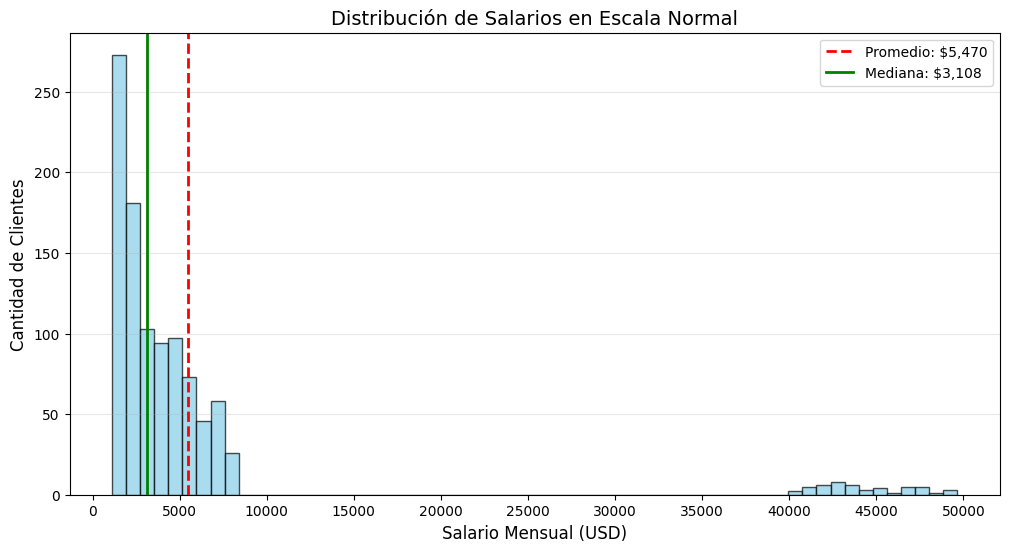

In [29]:
media = df['Sueldo_Num'].mean()
mediana = df['Sueldo_Num'].median()

plt.figure(figsize=(12, 6))

# Usamos escala normal (sin log)
plt.hist(df['Sueldo_Num'], bins=60, color='skyblue', edgecolor='black', alpha=0.7)

# Líneas de promedio y mediana
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Promedio: ${media:,.0f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: ${mediana:,.0f}')

# Configuración de ejes
plt.title('Distribución de Salarios', fontsize=14)
plt.xlabel('Salario Mensual (USD)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Ajustamos los ticks para que se vea el salto hasta los 50k
plt.xticks(np.arange(0, 55000, 5000))

plt.show()

###Analisis
Se nota que casi todo el mundo está amontonado en la primera barra de la izquierda (los sueldos de $1,000 a $8,000) y que hay un desierto gigante hasta llegar a los sueldos de $45,000 por allá al final. Lo que más me gusta es que se ve clarito cómo la línea roja del promedio se sale de la montaña de gente y se va hacia la derecha. El promedio no es confiable cuando la gráfica está así de estirada, y que la línea verde (la mediana) es la que de verdad me dice dónde está el cliente común.



##

##BOXPLOT

/tmp/ipykernel_156/2817741308.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Nivel Educativo', y='Sueldo_Num', data=df,


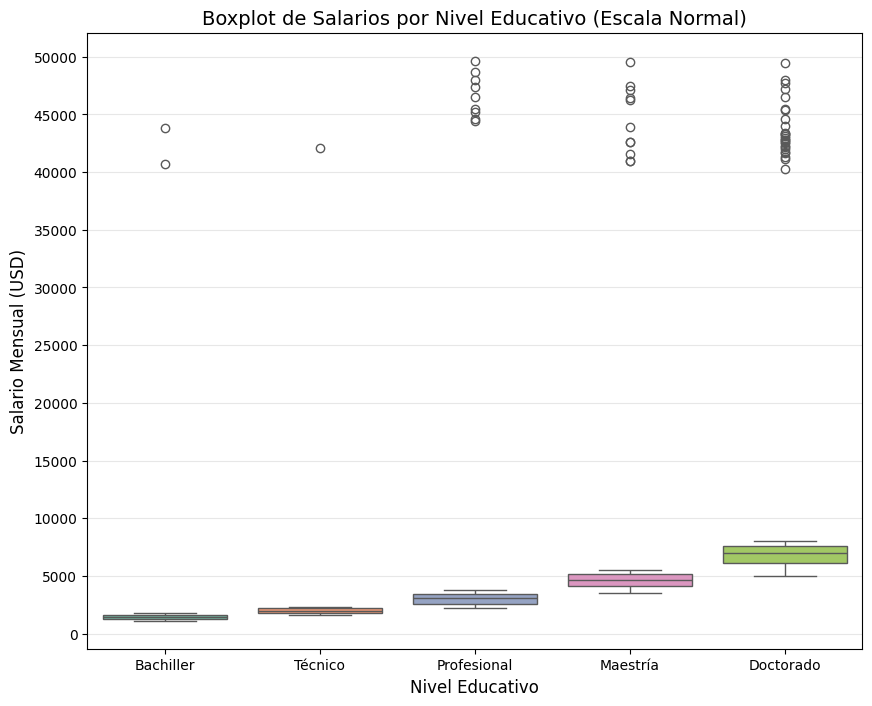

In [30]:
plt.figure(figsize=(10, 8))

# Graficamos el boxplot por nivel educativo
sns.boxplot(x='Nivel Educativo', y='Sueldo_Num', data=df,
            order=['Bachiller', 'Técnico', 'Profesional', 'Maestría', 'Doctorado'],
            palette='Set2')

# Detalles estéticos
plt.title('Boxplot de Salarios por Nivel Educativo (Escala Normal)', fontsize=14)
plt.xlabel('Nivel Educativo', fontsize=12)
plt.ylabel('Salario Mensual (USD)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Ajustamos los saltos del eje Y para que se vean los 50k
plt.yticks(np.arange(0, 55000, 5000))

plt.show()
plt.show()

#Analisis

Las cajas representan a la gente "normal" y se ve cómo van subiendo poquito a poquito según el nivel de estudio. Pero lo que más resalta son esos puntos negros que flotan allá arriba, cerca de los $45,000; esos son los valores atípicos (los "Outliers"). Este gráfico me sirve para explicar que la mayoría de los datos están concentrados abajo (en las cajas chiquitas), y que esos puntos locos son los que ensucian el promedio y hacen que la desviación estándar salga altísima.

##GRAFICO DE DISPERCION

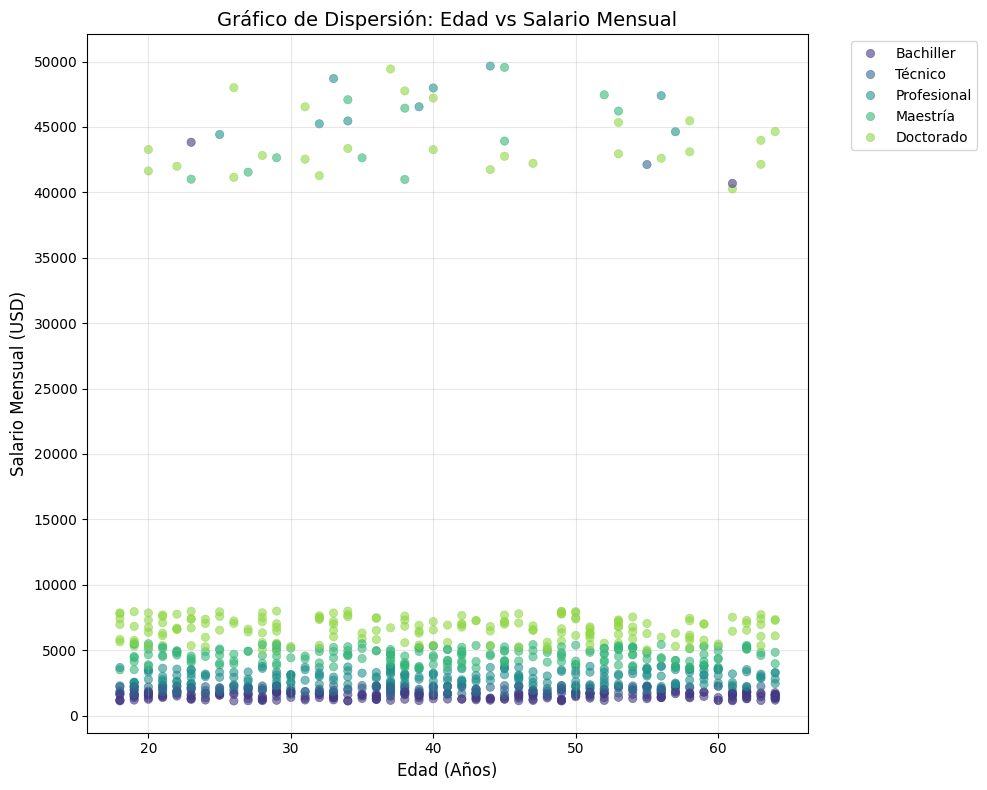

In [31]:
plt.figure(figsize=(10, 8))

# Graficamos Edad (Eje X) vs Salario Numérico (Eje Y)
# Usamos 'hue' para pintar los puntos según el Nivel Educativo (le da más sentido)
sns.scatterplot(x='Edad', y='Sueldo_Num', data=df, hue='Nivel Educativo',
                palette='viridis', alpha=0.6, edgecolor=None,
                hue_order=['Bachiller', 'Técnico', 'Profesional', 'Maestría', 'Doctorado'])

# Detalles estéticos
plt.title('Gráfico de Dispersión: Edad vs Salario Mensual', fontsize=14)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Salario Mensual (USD)', fontsize=12)
plt.grid(axis='both', alpha=0.3)

# Ajustamos los saltos del eje Y para que se vean los 50k
plt.yticks(np.arange(0, 55000, 5000))

# Movemos la leyenda para que no tape
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


Al cruzar Edad vs. Salario, el gráfico muestra que la gran mayoría de clientes están agrupados en la parte baja, subiendo ligeramente de sueldo conforme tienen más años y estudios (la "masa" de puntos). Sin embargo, los valores atípicos aparecen como puntos aislados en los $45,000, sin importar la edad que tengan. Esto me confirma visualmente que esos sueldos altos no siguen la lógica del resto del grupo y son los que "ensucian" mi promedio y disparan la desviación estándar, demostrando que el Cliente 5 es un caso excepcional que rompe la tendencia normal.